In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('Risk_Alert_Classifier_Dataset_4600 .csv')
df.head(7)

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0
5,500006,53.0,Female,East,Salaried,38733.0,691.0,0.625,0,2.1,68,17693.0,0,0,0,59,2025-10-10,21350,0
6,500007,26.0,Male,Central,Self-Employed,56641.0,611.0,0.115,0,0.7,76,38589.0,1,1,3,81,2025-09-04,15676,0


In [43]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [44]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


In [45]:
null_cols=[col for col in df.columns if df[col].isnull().sum()>0]
print(null_cols)
null_cols.remove('region')
null_cols.remove('employment_type')

['age', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'monthly_spend_inr']


In [46]:
null_cols

['age',
 'annual_income_inr',
 'credit_score',
 'credit_utilization_ratio',
 'monthly_spend_inr']

In [47]:
from sklearn.impute import SimpleImputer,KNNImputer
df[null_cols]=KNNImputer(n_neighbors=7).fit_transform(df[null_cols])
print(df.isnull().sum())

customer_id                    0
age                            0
gender                         0
region                       102
employment_type              144
annual_income_inr              0
credit_score                   0
credit_utilization_ratio       0
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr              0
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


In [48]:
df[['region','employment_type']]=SimpleImputer(strategy='most_frequent').fit_transform(df[['region','employment_type']])
df.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

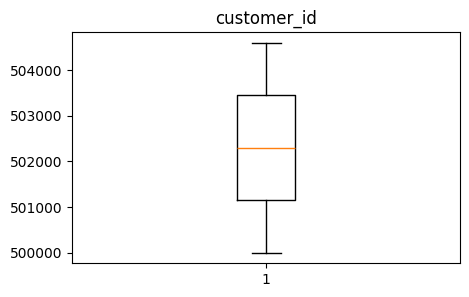

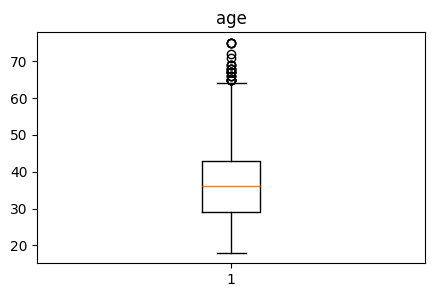

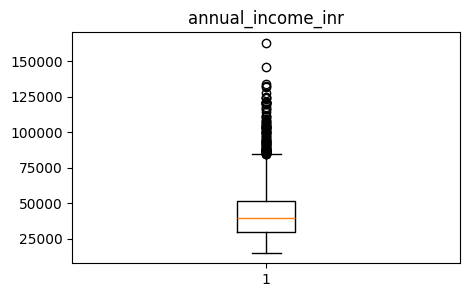

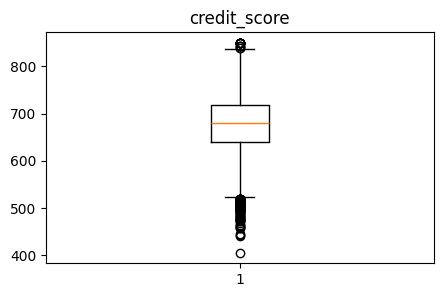

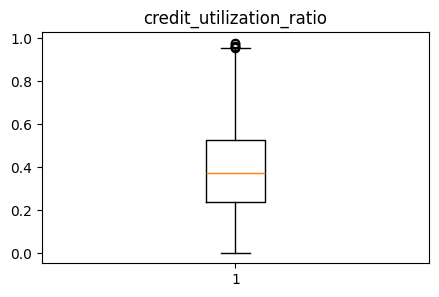

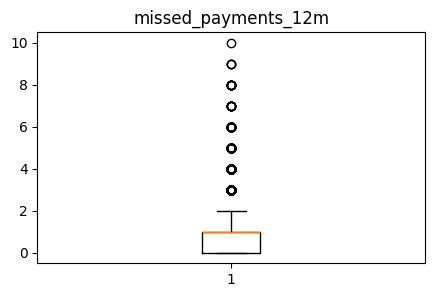

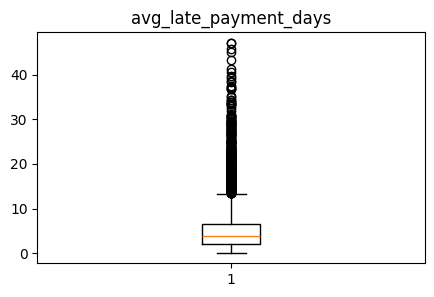

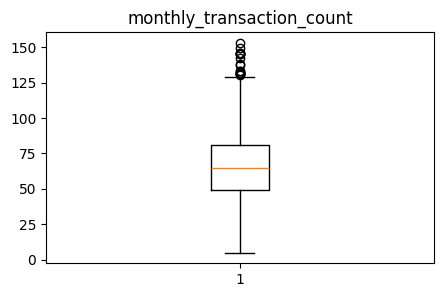

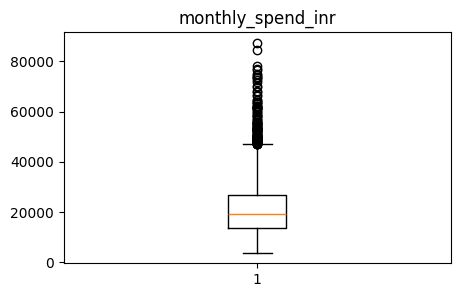

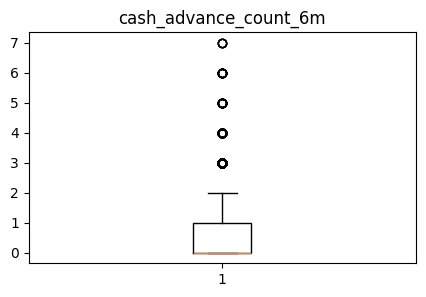

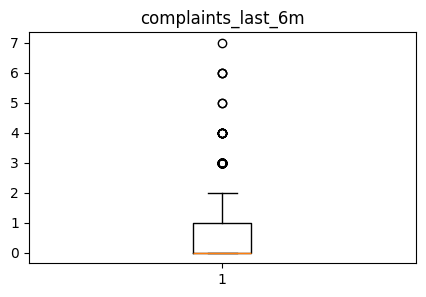

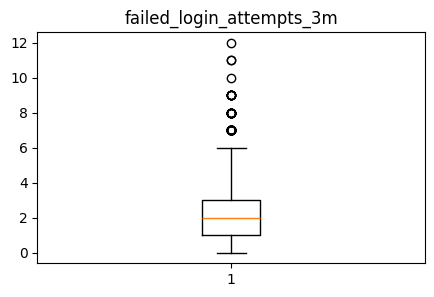

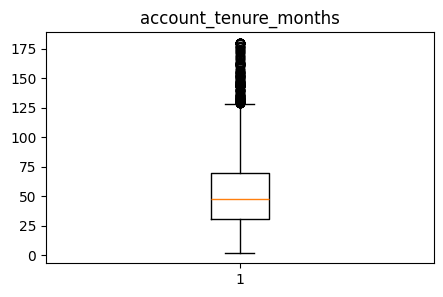

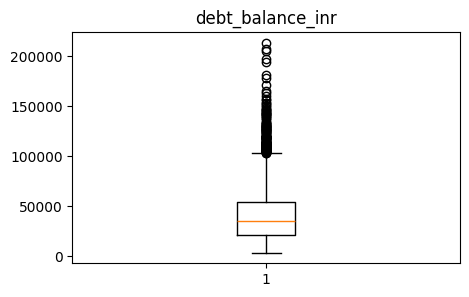

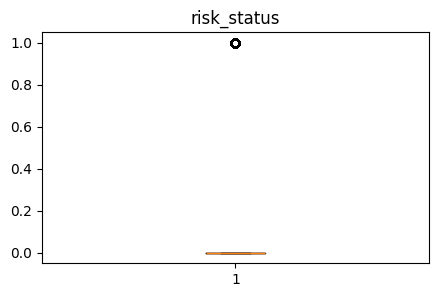

In [49]:
num_cols=df.select_dtypes(include=['int64','float64'])

for i in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [50]:
num_cols=num_cols.drop(columns=['customer_id','risk_status'])
print(num_cols.columns,'\n\nshape before removing outliers:',num_cols.shape)

Index(['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'debt_balance_inr'],
      dtype='object') 

shape before removing outliers: (4600, 13)


Shape before outliers removal

In [51]:
print(num_cols.shape)

(4600, 13)


In [52]:
for col in num_cols:
    q1 = num_cols[col].quantile(0.25)
    q3 = num_cols[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    num_cols = num_cols[(num_cols[col] >= lower_bound) & (num_cols[col] <= upper_bound)]

print("Shape after removing outliers:", num_cols.shape)

Shape after removing outliers: (3467, 13)


In [53]:
df[num_cols.columns] = num_cols

In [54]:
df.shape

(4600, 19)

In [55]:
df.dropna(inplace=True)
df.shape

(3467, 19)

In [56]:
df.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

Apply one hot encoding in categorical columns

In [57]:
df = pd.get_dummies(df, columns=['region', 'employment_type'], drop_first=True)
df

,customer_id,age,gender,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,...,debt_balance_inr,risk_status,region_East,region_North,region_South,region_West,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed
0,500001,43.0,Female,82242.0,634.714286,0.120,1.0,2.2,39.0,33889.0,...,87273.0,0,False,False,True,False,True,False,False,False
1,500002,29.0,Female,32769.0,647.000000,0.337,1.0,1.5,11.0,10853.0,...,20600.0,0,False,False,False,False,True,False,False,False
2,500003,36.0,Male,39731.0,727.000000,0.175,0.0,3.9,45.0,25519.0,...,47565.0,0,True,False,False,False,True,False,False,False
4,500005,36.0,Female,41043.0,732.000000,0.418,1.0,9.8,95.0,27114.0,...,12008.0,0,True,False,False,False,False,True,False,False
5,500006,53.0,Female,38733.0,691.000000,0.625,0.0,2.1,68.0,17693.0,...,21350.0,0,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4590,504591,18.0,Female,25315.0,699.000000,0.263,0.0,5.5,19.0,16190.0,...,27269.0,0,False,False,False,False,True,False,False,False
4592,504593,33.0,Male,71526.0,724.000000,0.451,0.0,3.5,51.0,26286.0,...,59952.0,0,True,False,False,False,True,False,False,False
4595,504596,40.0,Male,39337.0,645.000000,0.101,0.0,8.8,49.0,12591.0,...,28947.0,0,False,True,False,False,True,False,False,False
4597,504598,31.0,Female,45768.0,693.000000,0.583,1.0,7.1,36.0,16338.0,...,52776.0,0,True,False,False,False,False,True,False,False


Apply encoding in gender column

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['gender']

0       0
1       0
2       1
4       0
5       0
       ..
4590    0
4592    1
4595    1
4597    0
4599    0
Name: gender, Length: 3467, dtype: int32

Apply logistic regression

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X=df.drop(columns=['risk_status','last_transaction_date'])
y=df['risk_status']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [60]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[859   0]
 [  5   3]]

Accuracy: 0.994232987312572
Precision: 1.0
Recall: 0.375
F1 Score: 0.5454545454545454

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       859
           1       1.00      0.38      0.55         8

    accuracy                           0.99       867
   macro avg       1.00      0.69      0.77       867
weighted avg       0.99      0.99      0.99       867



In [61]:
TN, FP, FN, TP = cm.ravel()

print("Type-I Error (False Positive):", FP)
print("Type-II Error (False Negative):", FN)
print('TN:',TN,'TP:',TP)

Type-I Error (False Positive): 0
Type-II Error (False Negative): 5
TN: 859 TP: 3


Part D: Handling Imbalanced Data

In [62]:
print(y.value_counts())

print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

risk_status
0    3440
1      27
Name: count, dtype: int64

Percentage:
risk_status
0    99.221229
1     0.778771
Name: proportion, dtype: float64


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print('Recall :', recall_score(y_test, y_pred_base))
print('F1 Score :', f1_score(y_test, y_pred_base))
print('ROC-AUC :', roc_auc_score(y_test, y_pred_base))

Recall : 0.375
F1 Score : 0.5454545454545454
ROC-AUC : 0.6875


under_sampling

In [64]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train,y_train)
print(y_train_under.value_counts())

model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_train_under, y_train_under)
y_pred_under = model_under.predict(X_test)

under_recall = recall_score(y_test, y_pred_under)
under_f1 = f1_score(y_test, y_pred_under)
under_auc = roc_auc_score(y_test, y_pred_under)

print('Recall :', under_recall)
print('F1 :', under_f1)
print('ROC-AUC :', under_auc)

risk_status
0    19
1    19
Name: count, dtype: int64


Recall : 0.625
F1 : 0.21739130434782608
ROC-AUC : 0.793291618160652


over_sampling

In [65]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train,y_train)

print(y_train_over.value_counts())

model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_train_over, y_train_over)
y_pred_over = model_over.predict(X_test)

over_recall = recall_score(y_test, y_pred_over)
over_f1 = f1_score(y_test, y_pred_over)
over_auc = roc_auc_score(y_test, y_pred_over)

print("Recall :", over_recall)
print("F1 :", over_f1)
print("ROC-AUC :", over_auc)

risk_status
0    2581
1    2581
Name: count, dtype: int64
Recall : 0.375
F1 : 0.4
ROC-AUC : 0.6851717112922001


ADASYN

In [66]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train,y_train)

print(y_train_ada.value_counts())

model_ada = LogisticRegression(max_iter=1000)
model_ada.fit(X_train_ada, y_train_ada)
y_pred_ada = model_ada.predict(X_test)

ada_recall = recall_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)
ada_auc = roc_auc_score(y_test, y_pred_ada)

print('Recall :', ada_recall)
print('F1 :', ada_f1)
print('ROC-AUC :', ada_auc)

risk_status
0    2581
1    2576
Name: count, dtype: int64
Recall : 0.375
F1 : 0.42857142857142855
ROC-AUC : 0.6857537834691502


Comparison

In [67]:
import pandas as pd

results = pd.DataFrame({
    'Method': ['Baseline','Under Sampling','Over Sampling','ADASYN'],
    'Recall': [recall_score(y_test, y_pred_base),under_recall,over_recall,ada_recall],
    'F1 Score': [f1_score(y_test, y_pred_base),under_f1,over_f1,ada_f1],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_base),under_auc,over_auc,ada_auc]
})

print(results)

           Method  Recall  F1 Score   ROC-AUC
0        Baseline   0.375  0.545455  0.687500
1  Under Sampling   0.625  0.217391  0.793292
2   Over Sampling   0.375  0.400000  0.685172
3          ADASYN   0.375  0.428571  0.685754


Part E: Tree-Based Classification Models

* Decision tree

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", dt_accuracy)

Accuracy: 0.9850057670126874


* RandomForestClassifier

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9907727797001153


* Comparison

In [70]:
train_acc_rf = rf.score(X_train, y_train)
test_acc_rf = rf.score(X_test, y_test)
train_acc_dt = dt.score(X_train, y_train)
test_acc_dt = dt.score(X_test, y_test)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [train_acc_dt, train_acc_rf],
    'Test Accuracy': [test_acc_dt, test_acc_rf]
})

print(comparison)

           Model  Train Accuracy  Test Accuracy
0  Decision Tree             1.0       0.985006
1  Random Forest             1.0       0.990773


Part F: Hyperparameter Tuning
* Randomized Search CV

In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

dt_search = DecisionTreeClassifier(random_state=42)

param_dist_dt = {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 10, 15, 20, None], 'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8], 'max_features': ['sqrt', 'log2', None]}

random_dt = RandomizedSearchCV(estimator=dt_search, param_distributions=param_dist_dt, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_dt.fit(X_train, y_train)

print("Best Parameters:")
print(random_dt.best_params_)

print("Best CV Score:")
print(random_dt.best_score_)


Best Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'criterion': 'entropy'}
Best CV Score:
0.9923076923076923


In [72]:
from sklearn.metrics import accuracy_score

best_dt = random_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)
dt_tuned_acc = accuracy_score(y_test, y_pred_dt_tuned)
print("Tuned DT Accuracy:", dt_tuned_acc)

Tuned DT Accuracy: 0.9907727797001153


* Random Forest Hyperparameter Tuning

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_search = RandomForestClassifier(random_state=42)

param_dist_rf = {'n_estimators': [50, 100, 200, 300], 'max_depth': [5, 10, 15, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}

random_rf = RandomizedSearchCV(estimator=rf_search, param_distributions=param_dist_rf, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_rf.fit(X_train, y_train)

print("Best Parameters:")
print(random_rf.best_params_)

print("Best CV Score:")
print(random_rf.best_score_)


Best Parameters:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score:
0.9930769230769231


In [74]:
best_rf = random_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
rf_tuned_acc = accuracy_score(y_test, y_pred_rf_tuned)
print("Tuned RF Accuracy:", rf_tuned_acc)

Tuned RF Accuracy: 0.9907727797001153


Grid Search CV

In [75]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("Best CV Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:
0.9930769230769231


In [76]:
best_model = grid_rf.best_estimator_

y_pred_final = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred_final)
print("Final Accuracy:", final_acc)

Final Accuracy: 0.9907727797001153


Comparison

In [77]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Decision Tree Untuned','Decision Tree Tuned','Random Forest Untuned','Random Forest Tuned','Random Forest Grid Search'],
    'Accuracy': [test_acc_dt,dt_tuned_acc,test_acc_rf,rf_tuned_acc,final_acc]})

print(comparison)

                       Model  Accuracy
0      Decision Tree Untuned  0.985006
1        Decision Tree Tuned  0.990773
2      Random Forest Untuned  0.990773
3        Random Forest Tuned  0.990773
4  Random Forest Grid Search  0.990773


Part G: Model Evaluation & ROC Analysis

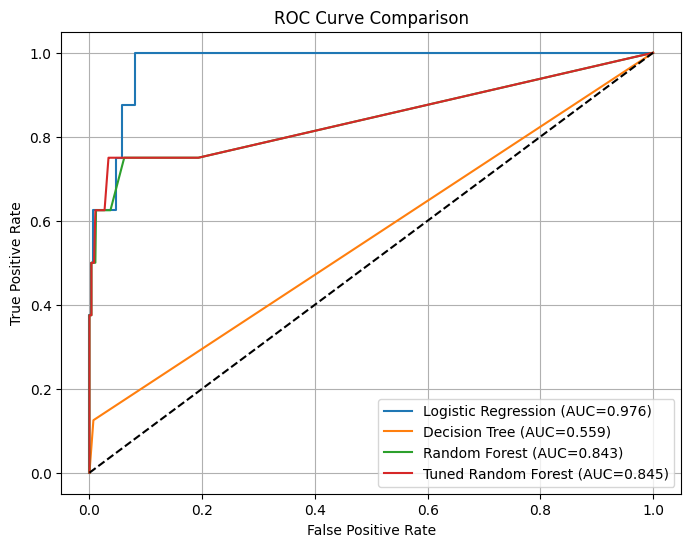

In [80]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr_prob = lr.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
best_rf_prob = best_model.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_best, tpr_best, _ = roc_curve(y_test, best_rf_prob)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt,label=f'Decision Tree (AUC={auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf,label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_best, tpr_best,label=f'Tuned Random Forest (AUC={auc_best:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)

plt.show()

Comparison

In [82]:
import pandas as pd

auc_results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','Tuned Random Forest'],
    'AUC-ROC': [auc_lr,auc_dt,auc_rf,auc_best]})

print(auc_results.sort_values(by='AUC-ROC',ascending=False))

                 Model   AUC-ROC
0  Logistic Regression  0.975553
3  Tuned Random Forest  0.845460
2        Random Forest  0.842841
1        Decision Tree  0.559008


Best model

In [86]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

results = []
models = {"Logistic Regression": lr,"Decision Tree": dt,"Random Forest": rf,"Tuned RF": best_model}

for name, m in models.items():

    pred = m.predict(X_test)
    results.append([name,accuracy_score(y_test, pred),recall_score(y_test, pred),f1_score(y_test, pred)])

comparison = pd.DataFrame(results, columns=['Model','Accuracy','Recall','F1 Score'])

print(comparison)

                 Model  Accuracy  Recall  F1 Score
0  Logistic Regression  0.994233   0.375  0.545455
1        Decision Tree  0.985006   0.125  0.133333
2        Random Forest  0.990773   0.000  0.000000
3             Tuned RF  0.990773   0.000  0.000000
